# Demand Analysis

This section focuses on understanding which skills and roles are most in demand in the data industry. It includes a breakdown of the Top 5 skills for key roles (Data Analyst, Engineer, Scientist) and an analysis of the demand distribution for each role across top hiring countries, highlighting where each role is most needed globally.

## Top 5 Skills for Top Data Roles

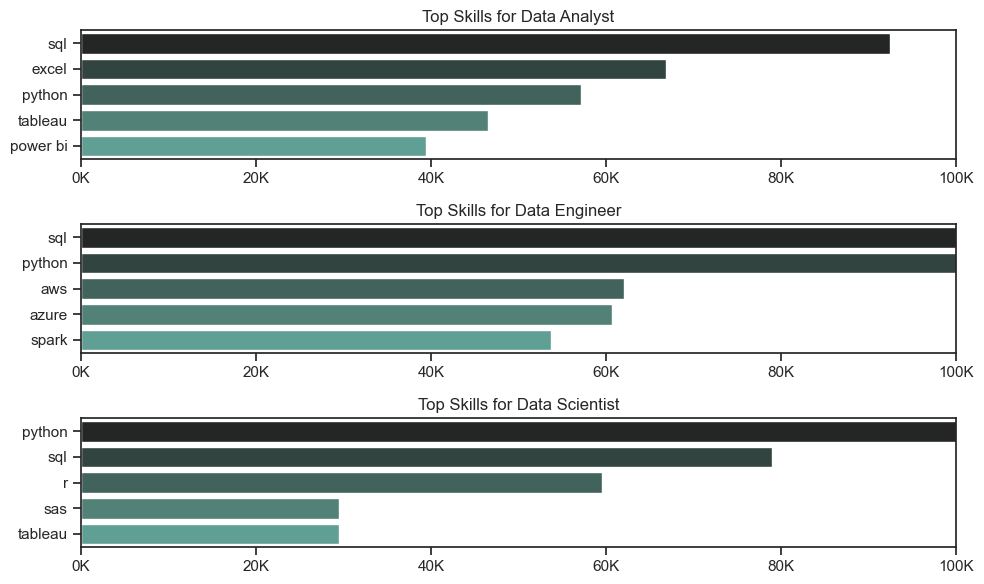

In [ ]:
# Prepare Data: Unpacks job skills and groups data
df_exploded = df.explode('job_skills')
df_grouped = df_exploded.groupby(['job_skills', 'job_title_short']).size().reset_index(name='skill_count')
data_plot = df_grouped.sort_values(by='skill_count', ascending=False)

# Build Data
job_titles = df['job_title_short'].value_counts().index[:3].to_list()

# Plot and Visualize
palette = sns.color_palette('dark:#5A9_r', 5)

fig, axes = plt.subplots(len(job_titles), 1, figsize=(10, 6))

for i, job_title in enumerate(job_titles):
    df_plot = data_plot[data_plot['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=axes[i], palette=palette, hue='skill_count')
    axes[i].set_title(f"Top Skills for {job_title}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, 100000)
    axes[i].get_legend().remove()
    axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

SQL and Python dominate across all roles, showing their fundamental importance in querying, processing, and analyzing data. Visualization tools (Tableau, Power BI) remain critical for Analysts, reflecting the demand for business-ready insights. Cloud and big data technologies (AWS, Azure, Spark) are critical differentiators for Data Engineers, highlighting the industry's shift towards scalable infrastructure. While the skills demanded of a Data Scientists come with a mix of heavier programming (Python) and R/SAS which is often used in research-heavy or statistical tools (R/SAS).

## Distribution of Demand Across Top Data Roles in Different Countries

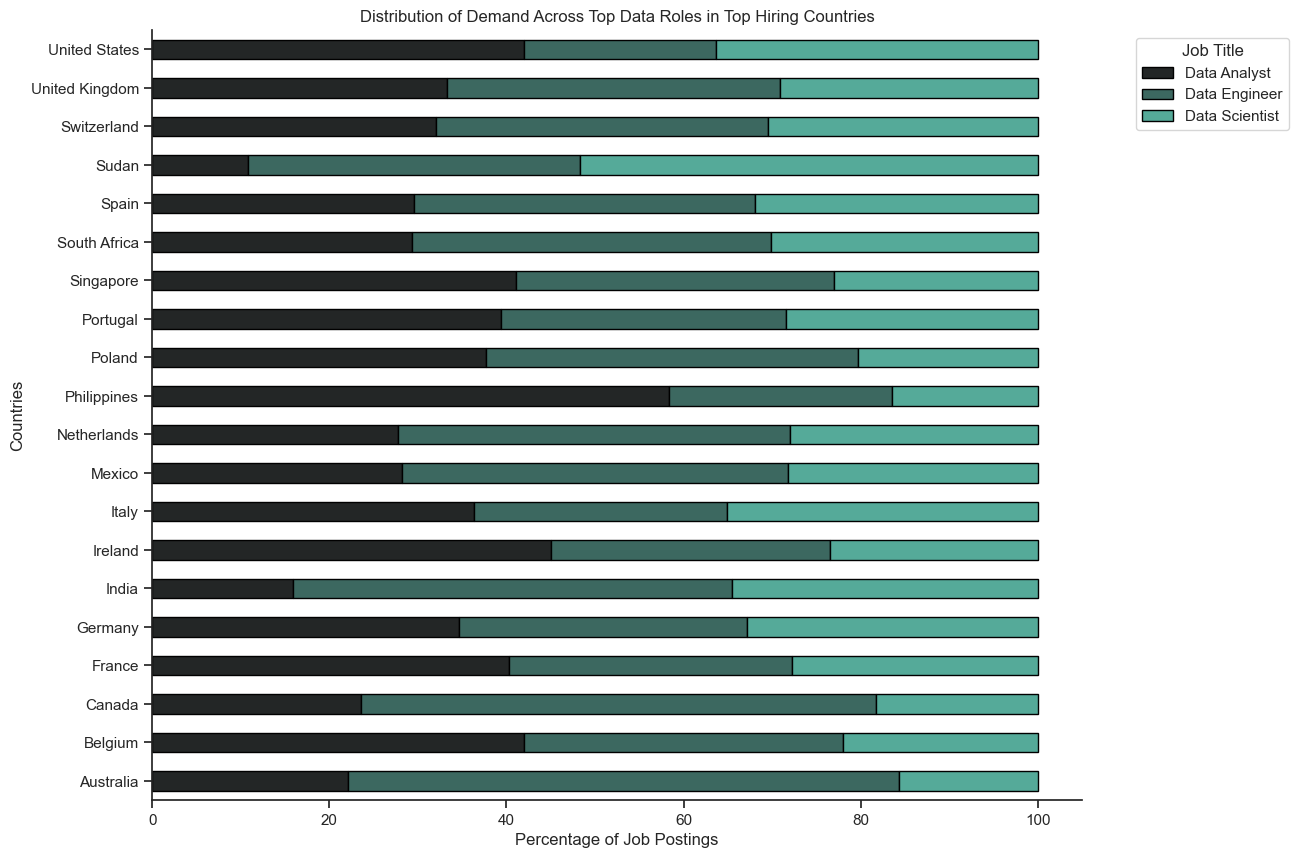

In [3]:
# Import Libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Prepare Data: Gets (a) top countries and (b) top titles to filter the original dataframe
top_countries = df['job_country'].value_counts().index[:20].to_list()
top_titles = df['job_title_short'].value_counts().index[:3].to_list()
df_filtered = df[df['job_country'].isin(top_countries) & df['job_title_short'].isin(top_titles)]

# Build Data: Groups data and calculates the percentages for each country
df_grouped = df_filtered.groupby(['job_country', 'job_title_short']).size().reset_index(name='job_counts')
df_pivot = df_grouped.pivot_table(index='job_country', columns='job_title_short', values='job_counts', fill_value=0)
df_percentage = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Plot and Visualize
sns.set_theme(style='ticks')
palette = sns.color_palette('dark:#5A9', n_colors=len(df_percentage.columns))
ax = df_percentage.plot(kind='barh', stacked=True, figsize=(12, 10), edgecolor='black', color=palette)
sns.despine()

plt.title('Distribution of Demand Across Top Data Roles in Top Hiring Countries')
plt.xlabel('Percentage of Job Postings')
plt.ylabel('Countries')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Data Analyst roles dominate in the United States, Singapore, Portugal, and the Philippines, reflecting their reliance on operational reporting and business intelligence across service-driven sectors. Data Engineer demand is strong in India, Poland, and Canada, most likely driven by tech outsourcing, cloud infrastructure, and large-scale data pipeline needs. Interestingly, Sudan is the sole country that prioritizes Data Scientists above all, suggesting a focus on data-intensive projects. And only European countries like UK, Germany, and France, as well as Canada, exhibit balanced distributions which can reflect their mature economies requiring holistic data teams.